In [1]:
# 18/05 10:00 AM

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import os as os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



pd.set_option('display.max_colwidth',700)
pd.set_option('display.max_columns',None)

os.listdir('/content/drive/MyDrive/Colab Notebooks/Supervised Learning/WhatsApp Chat Analysis/')


['WhatsApp Chat with Competitive Programmers.txt',
 'hindi_stop_words.txt',
 "what's_chat_analysis.ipynb"]

In [3]:

path = '/content/drive/MyDrive/Colab Notebooks/Supervised Learning/WhatsApp Chat Analysis/WhatsApp Chat with Competitive Programmers.txt'


with open(path, encoding='utf-8') as file:
  file_data = file.read()


len(file_data)

1597604

In [4]:
file_data

'10/6/20, 7:09\u202fPM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n1/28/20, 9:45\u202fPM - +91 94088 93107 created group "Competitive Programmers"\n10/6/20, 7:09\u202fPM - You joined using this group\'s invite link\n10/6/20, 7:10\u202fPM - +91 72928 89444: yes\n10/6/20, 7:10\u202fPM - +91 72928 89444: C. option\n10/6/20, 7:10\u202fPM - +91 72928 89444: O(nlogn)\n10/6/20, 7:12\u202fPM - +91 72928 89444: how n^2 bhaia\n10/6/20, 7:13\u202fPM - +91 72928 89444: <Media omitted>\n10/6/20, 8:03\u202fPM - +91 70115 09528: bhai koi h yha pe jo codechef pe practice krta ho or NZEC  error ajate h hr program m uska ya na ae to wrong answr ata h\n10/6/20, 8:09\u202fPM - +91 72928 89444: question no\n10/6/20, 8:20\u202fPM - +91 98499 81675: B\n10/6/20, 8:26\u202fPM - +91 98347 58456: Ohh... This is right\n10/6/20, 8:29\u202fPM - +91 95407 65311: #include <iostream>\nusing namespace std;\n\nint main() {\n    int t;\n    cin

In [5]:
file_data = file_data.replace('\u202f',' ')


In [6]:

# 18/5/24, 9:41 -

pattern = r'\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{1,2}\s[AP]M\s-\s'

message = re.split(pattern,file_data)[1:]

message[1:20]


['+91 94088 93107 created group "Competitive Programmers"\n',
 "You joined using this group's invite link\n",
 '+91 72928 89444: yes\n',
 '+91 72928 89444: C. option\n',
 '+91 72928 89444: O(nlogn)\n',
 '+91 72928 89444: how n^2 bhaia\n',
 '+91 72928 89444: <Media omitted>\n',
 '+91 70115 09528: bhai koi h yha pe jo codechef pe practice krta ho or NZEC  error ajate h hr program m uska ya na ae to wrong answr ata h\n',
 '+91 72928 89444: question no\n',
 '+91 98499 81675: B\n',
 '+91 98347 58456: Ohh... This is right\n',
 "+91 95407 65311: #include <iostream>\nusing namespace std;\n\nint main() {\n    int t;\n    cin>>t;\n    while(t--){\n        long long int n,k;\n        cin>>n>>k;\n        int arr[1000];\n        for (int i=0;i<n;i++){\n            cin>>arr[i];\n        }\n        \n        for(int i=0;i<n;i++){\n            if(arr[i]%k==0){\n                cout<<'1';\n            }\n            else{\n                cout<<'0';\n            }\n        }\n    }\n\treturn 0;\n}\n",


In [7]:
dates = re.findall(pattern,file_data)

dates[1:10]

['1/28/20, 9:45 PM - ',
 '10/6/20, 7:09 PM - ',
 '10/6/20, 7:10 PM - ',
 '10/6/20, 7:10 PM - ',
 '10/6/20, 7:10 PM - ',
 '10/6/20, 7:12 PM - ',
 '10/6/20, 7:13 PM - ',
 '10/6/20, 8:03 PM - ',
 '10/6/20, 8:09 PM - ']

In [8]:
len(message), len(dates)

(18941, 18941)

In [9]:
data = pd.DataFrame({'user_message':message,'message_dates':dates})

data.head()

,user_message,message_dates
0,"Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n","10/6/20, 7:09 PM -"
1,"+91 94088 93107 created group ""Competitive Programmers""\n","1/28/20, 9:45 PM -"
2,You joined using this group's invite link\n,"10/6/20, 7:09 PM -"
3,+91 72928 89444: yes\n,"10/6/20, 7:10 PM -"
4,+91 72928 89444: C. option\n,"10/6/20, 7:10 PM -"


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18941 entries, 0 to 18940
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   user_message   18941 non-null  object
 1   message_dates  18941 non-null  object
dtypes: object(2)
memory usage: 296.1+ KB


In [11]:
data['message_dates'] = (data['message_dates'].str.replace(' -',' ',regex=False).str.strip())


In [12]:
data['message_dates'].iloc[0]

'10/6/20, 7:09 PM'

In [13]:
# 10/6/20, 7:09 PM

data['message_dates'] = pd.to_datetime(data['message_dates'],format= '%m/%d/%y, %I:%M %p', errors='coerce')
# data.rename(columns={'message_dates': 'date'},inplace=True)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18941 entries, 0 to 18940
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_message   18941 non-null  object        
 1   message_dates  18941 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 296.1+ KB


In [15]:
data.head(10)

,user_message,message_dates
0,"Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n",2020-10-06 19:09:00
1,"+91 94088 93107 created group ""Competitive Programmers""\n",2020-01-28 21:45:00
2,You joined using this group's invite link\n,2020-10-06 19:09:00
3,+91 72928 89444: yes\n,2020-10-06 19:10:00
4,+91 72928 89444: C. option\n,2020-10-06 19:10:00
5,+91 72928 89444: O(nlogn)\n,2020-10-06 19:10:00
6,+91 72928 89444: how n^2 bhaia\n,2020-10-06 19:12:00
7,+91 72928 89444: <Media omitted>\n,2020-10-06 19:13:00
8,+91 70115 09528: bhai koi h yha pe jo codechef pe practice krta ho or NZEC error ajate h hr program m uska ya na ae to wrong answr ata h\n,2020-10-06 20:03:00
9,+91 72928 89444: question no\n,2020-10-06 20:09:00


In [16]:
data['user_message'].iloc[100:120]

,user_message
100,+91 77758 75403: Okay\n
101,+91 77758 75403: Programming related topic haina\n
102,"+91 72928 89444: Coding k liye important h,\nLogical subject h\n"
103,+91 94205 81813: Ohh\n
104,"+91 72928 89444: Mast logic lagta h isse, help milta h\n"
105,+91 77758 75403: Okay mai diploma ka student hu to ye subject kar sakta kya ab\n
106,+91 72928 89444: Jaise no. Of rectangle made from 8 lines\n
107,+91 72928 89444: Are bhai subject padhne k liye degree kahan important h\n
108,+91 72928 89444: 🤩\n
109,+91 72928 89444: Araam se padh sakte h\n


In [17]:
# Day 02 - 20/05 10:25 AM

users = []
messages = []

for message in data['user_message']:
  # entry = re.split(r'([\w\W+]):\s',message)
  entry = re.split(r'(.*?):\s',message)
  if entry[1:]:
    users.append(entry[1])
    messages.append("".join(entry[2]))
  else:
    users.append('user-notification')
    messages.append(entry[0])


data['user'] = users
data['message'] = messages
data.drop(columns=['user_message'],inplace=True)


In [18]:
data.head()

,message_dates,user,message
0,2020-10-06 19:09:00,user-notification,"Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n"
1,2020-01-28 21:45:00,user-notification,"+91 94088 93107 created group ""Competitive Programmers""\n"
2,2020-10-06 19:09:00,user-notification,You joined using this group's invite link\n
3,2020-10-06 19:10:00,+91 72928 89444,yes\n
4,2020-10-06 19:10:00,+91 72928 89444,C. option\n


In [19]:
data['user'].nunique()

333

In [20]:
data.dtypes

,0
message_dates,datetime64[ns]
user,object
message,object


In [21]:
data['message_dates'].dtype

dtype('<M8[ns]')

In [23]:
data['date'] = data['message_dates'].dt.date
data['day'] = data['message_dates'].dt.day
data['day_name'] = data['message_dates'].dt.day_name()
data['hour'] = data['message_dates'].dt.hour
data['minutes'] = data['message_dates'].dt.minute
data['month'] = data['message_dates'].dt.month
data['month_name'] = data['message_dates'].dt.month_name()
data['year'] = data['message_dates'].dt.year




In [25]:
data.dtypes

,0
message_dates,datetime64[ns]
user,object
message,object
date,object
day,int32
day_name,object
hour,int32
minutes,int32
month,int32
month_name,object


In [26]:
data.drop(columns=['message_dates'],inplace=True)

In [27]:
period = []
for hour in data['hour']:
    if hour == 23:
        period.append(str(hour) + "-" + str('00'))
    elif hour == 0:
        period.append(str('00') + "-" + str(hour + 1))
    else:
        period.append(str(hour) + "-" + str(hour + 1))

data['period'] = period

data.head()

,user,message,date,day,day_name,hour,minutes,month,month_name,year,period
0,user-notification,"Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n",2020-10-06,6,Tuesday,19,9,10,October,2020,19-20
1,user-notification,"+91 94088 93107 created group ""Competitive Programmers""\n",2020-01-28,28,Tuesday,21,45,1,January,2020,21-22
2,user-notification,You joined using this group's invite link\n,2020-10-06,6,Tuesday,19,9,10,October,2020,19-20
3,+91 72928 89444,yes\n,2020-10-06,6,Tuesday,19,10,10,October,2020,19-20
4,+91 72928 89444,C. option\n,2020-10-06,6,Tuesday,19,10,10,October,2020,19-20


In [28]:
# Display Basic Statistics for Data Analysis

data.shape

(18941, 11)

In [50]:
data['message']

,message
108,🤩\n
109,Araam se padh sakte h\n
110,😇👍\n
111,Maza ayega\n
112,Isme\n
...,...
18936,Your security code with +91 70119 85828 changed. Tap to learn more.\n
18937,Your security code with ~ Sahil changed. Tap to learn more.\n
18938,Your security code with ~ 5Pyd3r changed. Tap to learn more.\n
18939,Your security code with ~ ~avi~ changed. Tap to learn more.\n


In [30]:
words = data['message'].dropna().astype(str).str.replace('\n','').str.split().sum()

words


['Messages',
 'and',
 'calls',
 'are',
 'end-to-end',
 'encrypted.',
 'Only',
 'people',
 'in',
 'this',
 'chat',
 'can',
 'read,',
 'listen',
 'to,',
 'or',
 'share',
 'them.',
 '*Learn',
 'more*',
 '+91',
 '94088',
 '93107',
 'created',
 'group',
 '"Competitive',
 'Programmers"',
 'You',
 'joined',
 'using',
 'this',
 "group's",
 'invite',
 'link',
 'yes',
 'C.',
 'option',
 'O(nlogn)',
 'how',
 'n^2',
 'bhaia',
 '<Media',
 'omitted>',
 'bhai',
 'koi',
 'h',
 'yha',
 'pe',
 'jo',
 'codechef',
 'pe',
 'practice',
 'krta',
 'ho',
 'or',
 'NZEC',
 'error',
 'ajate',
 'h',
 'hr',
 'program',
 'm',
 'uska',
 'ya',
 'na',
 'ae',
 'to',
 'wrong',
 'answr',
 'ata',
 'h',
 'question',
 'no',
 'B',
 'Ohh...',
 'This',
 'is',
 'right',
 '#include',
 '<iostream>using',
 'namespace',
 'std;int',
 'main()',
 '{',
 'int',
 't;',
 'cin>>t;',
 'while(t--){',
 'long',
 'long',
 'int',
 'n,k;',
 'cin>>n>>k;',
 'int',
 'arr[1000];',
 'for',
 '(int',
 'i=0;i<n;i++){',
 'cin>>arr[i];',
 '}',
 'for(int',
 

In [31]:
# Media files

data[data['message'] == '<Media omitted>\n'].shape[0]


1625

In [32]:
! pip install urlextract

In [33]:
from urlextract import URLExtract

extract = URLExtract()

links = []

for link in data['message']:
  links.extend(extract.find_urls(link))

print(links)





['https://www.codechef.com/problems/CHEFSTEP', 'https://chat.whatsapp.com/IM9u21HdXqT54H4HokQ2vx', 'https://www.codechef.com/OCT20B/problems/ADDSQURE', 'FreeCourseSite.com', 'http://FreeCourseSite.com', 'Carrierride.com', 'Geeksforgeeks.com', 'Compscibits.com', 'Learnerindia.com', 'Gkseries.com', 'Cs-mcqs.blogspot.com', 'https://youtu.be/sXW2VLrQ3Bs', 'collection.java', 'https://www.hackerrank.com/challenges/crossword-puzzle/problem', 'https://youtu.be/X7SrnbgqHHs', 'System.in', 'https://youtu.be/R-dnueSvnsU', 'learner.You', 'https://www.crio.do/IBelieveInDoing/October', 'types.It', 'https://www.codechef.com/OCT20B/problems/REPLESX', 'https://internshala.com/easiest-internships-ever?utm_source=refer_copylink&utm_medium=9027376', 'https://youtu.be/dT6dvdbpChA', 'algoexpert.io', 'https://mega.nz/folder/KqYiVCYL', 'https://mega.nz/file/i2oHFLgZ', 'https://mega.nz/folder/OmIiDKpT', 'https://mega.nz/folder/lihzlQiJ', 'https://mega.nz/folder/Eu4HjYgD', 'https://mega.nz/folder/GUhHyaxC', 'htt

In [52]:
# Find the Busiest Users in Group

data.head()

,user,message,date,day,day_name,hour,minutes,month,month_name,year,period
0,user-notification,"Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. *Learn more*\n",2020-10-06,6,Tuesday,19,9,10,October,2020,19-20
1,user-notification,"+91 94088 93107 created group ""Competitive Programmers""\n",2020-01-28,28,Tuesday,21,45,1,January,2020,21-22
2,user-notification,You joined using this group's invite link\n,2020-10-06,6,Tuesday,19,9,10,October,2020,19-20
3,+91 72928 89444,yes\n,2020-10-06,6,Tuesday,19,10,10,October,2020,19-20
4,+91 72928 89444,C. option\n,2020-10-06,6,Tuesday,19,10,10,October,2020,19-20


<BarContainer object of 5 artists>

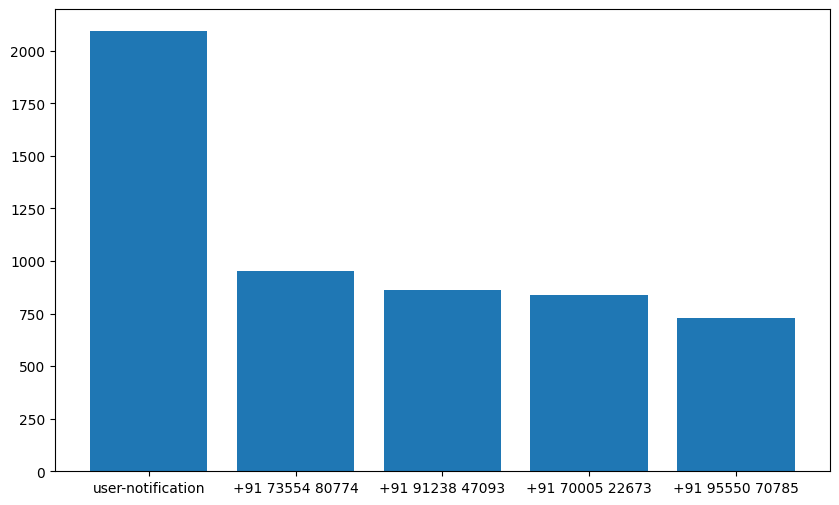

In [35]:

user = data['user'].value_counts().head()

user_name = user.index
count = user.to_numpy()

plt.figure(1, figsize=(10,6))
plt.bar(user_name,count)
# plt.xticks(rotation='vertical')


In [36]:
# percentage

active_percent = round(((data['user'].value_counts() / data.shape[0]) * 100),2).reset_index().rename(columns={'index':'name','count':'percent'})

active_percent.head()

,user,percent
0,user-notification,11.05
1,+91 73554 80774,5.03
2,+91 91238 47093,4.56
3,+91 70005 22673,4.42
4,+91 95550 70785,3.85


In [37]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stopwords_list = set(stopwords.words('english'))

def hindi_stopwords(message):
  with open('/content/drive/MyDrive/Colab Notebooks/Supervised Learning/WhatsApp Chat Analysis/hindi_stop_words.txt', 'r') as file:
    stop_words = file.read()

  filtered_message = []
  for word in message.lower().split():
      if word not in stop_words:
          filtered_message.append(word)
  return " ".join(filtered_message)

def english_stopwrods(message):
  filtered_message = []
  for word in message.lower().split():
    if word not in stopwords_list:
      filtered_message.append(word)
  return " ".join(filtered_message)

def remove_punctuation(message):
  return  re.sub(r'[^\w\s]', '', message)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [53]:

temp = data[data['user'] != 'user-notification']
temp = temp[temp['message'] != '<Media omitted>\n']


temp['message'] = temp['message'].apply(hindi_stopwords)
temp['message'] = temp['message'].apply(english_stopwrods)
temp['message'] = temp['message'].apply(remove_punctuation)




KeyboardInterrupt: 

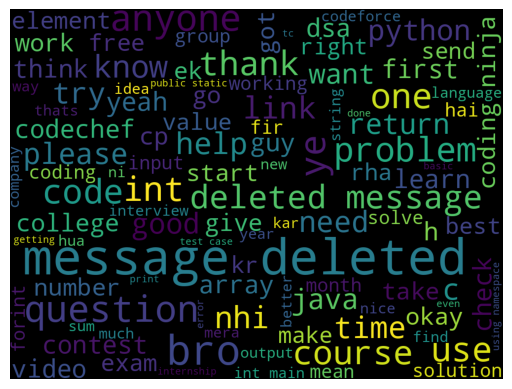

In [39]:
from wordcloud import WordCloud


wc = WordCloud(width= 1000, height= 750, min_font_size=20, random_state= 21, max_font_size=100).generate(temp['message'].str.cat(sep=' '))
plt.axis('off')
plt.imshow(wc)

In [40]:
# ind the Top 20 Most Common Words
from collections import Counter

words = []

for msg in temp['message']:
  words.extend(msg.split())



common_words = pd.DataFrame(Counter(words).most_common(10))

common_words



,0,1
0,int,700
1,anyone,620
2,message,551
3,deleted,535
4,1,463
5,bro,389
6,course,380
7,please,343
8,code,326
9,help,299


In [45]:
! pip install emoji

In [57]:
temp['message'].iloc[108:120]

,message
124,Personally\n
125,Ha okay\n
126,Ap kon se yr m h\n
127,3rd year\n
128,🙏\n
129,"3sem m hu abhi,hume to start hi krwaya gya h\n"
130,Ap kisi aur knowledgeable bhaia se guide le liye\n
131,Mere pas khud adha knowledge h😅\n
132,Waise link vejta hu apko👍\n
133,Okay 👍 aap Coursera ke courses bhej dijiye\n


In [61]:
import emoji

emoji_list = []

for msg in temp['message']:
  emoji_list.extend([ c for c in msg if c in emoji.EMOJI_DATA])

common_emoji = pd.DataFrame(Counter(emoji_list).most_common(len(Counter(emoji_list))))

common_emoji.head(10)

,0,1
0,😂,905
1,🤣,331
2,😅,273
3,🏻,234
4,👍,215
5,🙏,177
6,🥲,99
7,🥺,78
8,🙂,77
9,🔥,69


In [62]:
data.columns

Index(['user', 'message', 'date', 'day', 'day_name', 'hour', 'minutes',
       'month', 'month_name', 'year', 'period'],
      dtype='object')

In [66]:
# Time-based Analysis

timeline = data.groupby(['month','month_name','year'])['message'].count().reset_index()

timeline.head()



,month,month_name,year,message
0,1,January,2020,1
1,1,January,2021,1973
2,1,January,2022,386
3,1,January,2023,40
4,1,January,2024,12


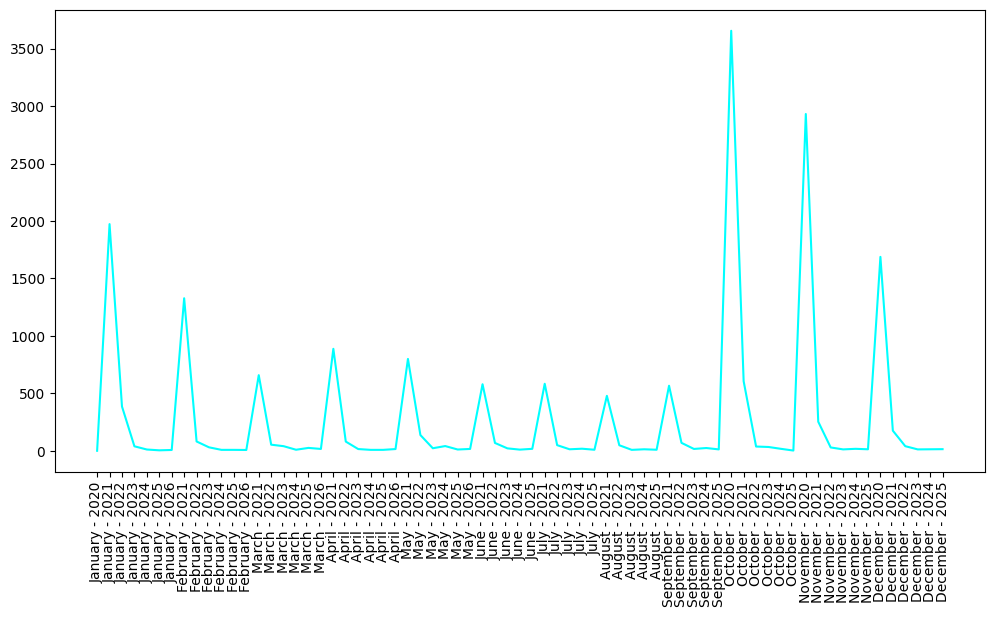

In [102]:
month_timeline = []

for i in range(timeline.shape[0]):
  month_timeline.append(timeline['month_name'][i]+ ' - '+ str(timeline['year'][i]))

timeline['monthly_timeline'] = month_timeline

plt.figure(figsize=(12,6))
plt.plot(timeline['monthly_timeline'], timeline['message'], color='cyan')
plt.xticks(rotation='vertical')
plt.show()

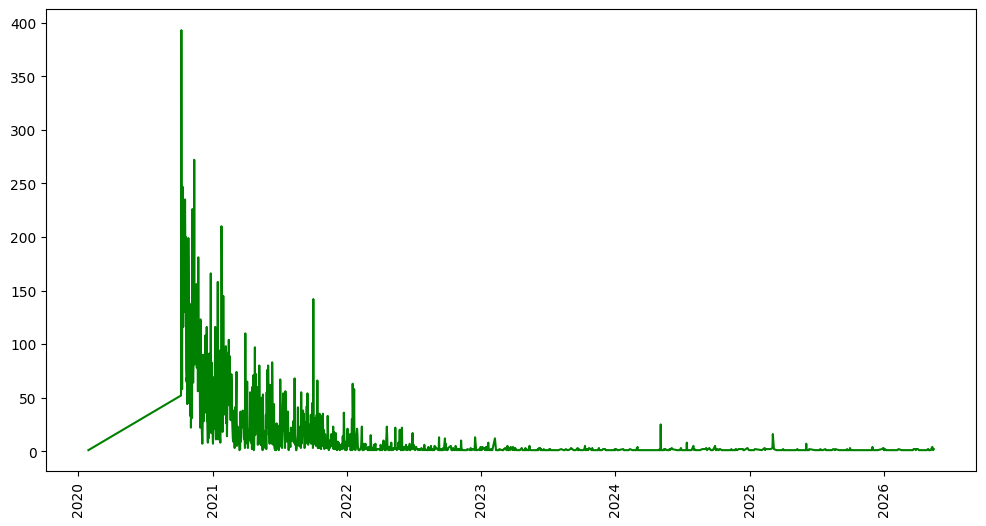

In [101]:
# Daily Timeline

daily = data.groupby('date')['message'].count().reset_index()

# timeline['daily_timeline'] = daily

plt.figure(figsize=(12,6))
plt.plot(daily['date'], daily['message'], color='green')
plt.xticks(rotation='vertical')
plt.show()



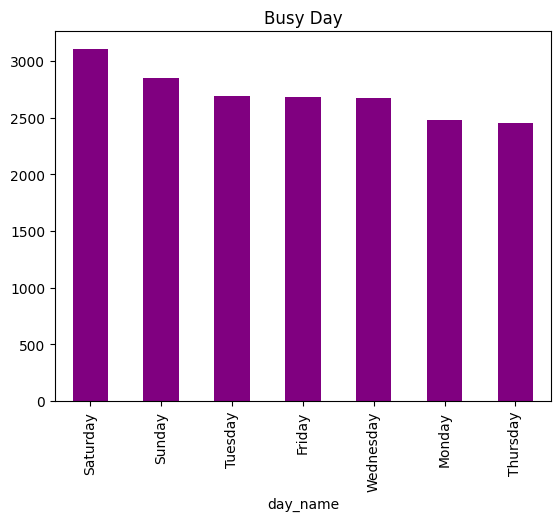

In [97]:
# Day-based Activity Map

plt.title("Busy Day")
day_based = data['day_name'].value_counts().plot.bar(color='purple')




In [88]:
data.columns

Index(['user', 'message', 'date', 'day', 'day_name', 'hour', 'minutes',
       'month', 'month_name', 'year', 'period'],
      dtype='object')

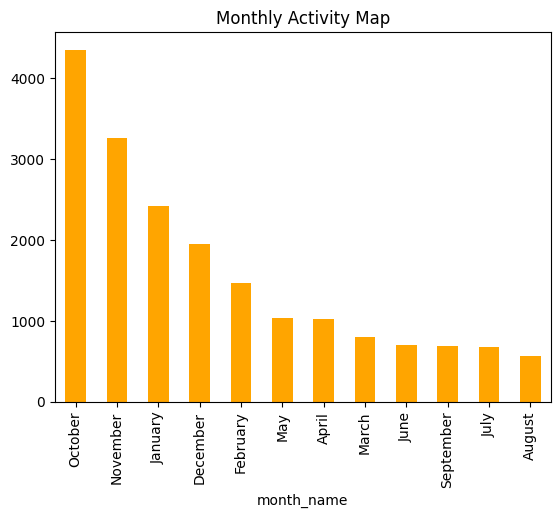

In [99]:
# Monthly Activity Map

plt.title("Monthly Activity Map")
day_based = data['month_name'].value_counts().plot.bar(color='orange')


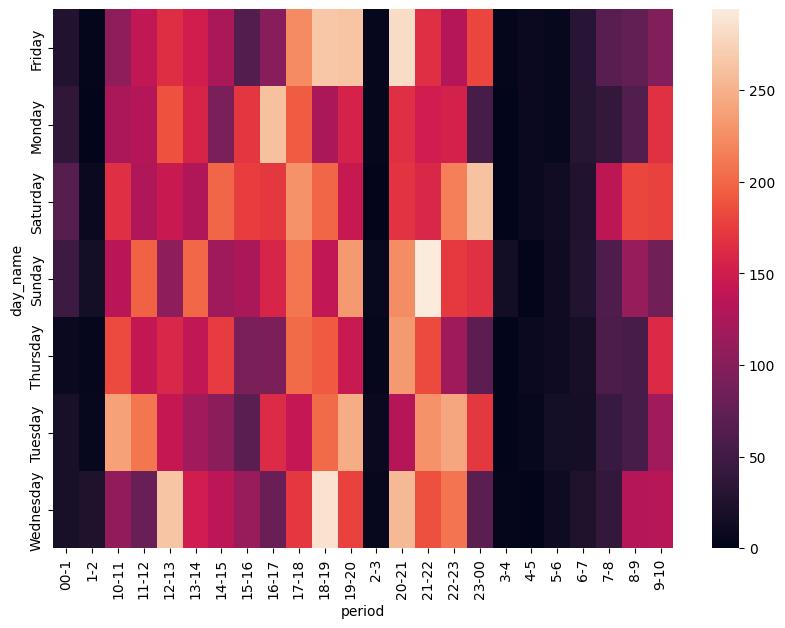

In [107]:

plt.figure(1, figsize=(10,7))
sns.heatmap(data.pivot_table(index='day_name', columns='period', values='message',
            aggfunc='count').fillna(0))
plt.yticks(rotation='vertical')
plt.show()